# Chronos-2 — Electricity Load Forecasting
**Darekar, Kim, Saxena | University of Trier | RCS SS2026**

Run cells **top to bottom**. Each section is one scenario from the Exposé.

In [2]:
# Standard library and third-party imports
import sys, os
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline
from transformers.utils.logging import disable_progress_bar

# Add src/ to path so notebook can import our modules
sys.path.insert(0, os.path.join(os.getcwd(), "src"))
warnings.filterwarnings("ignore")

from config          import RESULTS_DIR, DATA_DIR, MODEL_ID, TARGET_COLUMN
from data_loader     import pan_load, pan_preprocessing, aus_convert_tsf_to_dataframe, aus_preprocessing
from metrics         import calculate_metrics, compute_summary_statistics
from plots           import plot_metrics_boxplots, plot_distribution, plot_time_series
from scenarios       import s1_predict, s1_evaluation

print("All imports OK")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")

All imports OK
PyTorch  : 2.11.0+cpu
Device   : cpu


## 1 — Load and Preprocess Data

1.1. Panama


--- Panama (PAN) Electricity Load Dataset ---
                 datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc  \
0     2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174   
1     2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418   
2     2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480   
3     2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273   
4     2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281   
...                   ...         ...        ...       ...       ...   
48043 2020-06-26 20:00:00   1128.5592  27.246545  0.020303  0.055511   
48044 2020-06-26 21:00:00   1112.7488  27.099573  0.020395  0.053848   
48045 2020-06-26 22:00:00   1081.5680  26.971155  0.020448  0.057251   
48046 2020-06-26 23:00:00   1041.6240  26.867487  0.020464  0.064178   
48047 2020-06-27 00:00:00   1013.5683  26.750330  0.020441  0.063965   

         W2M_toc    T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  \
0      21.85054

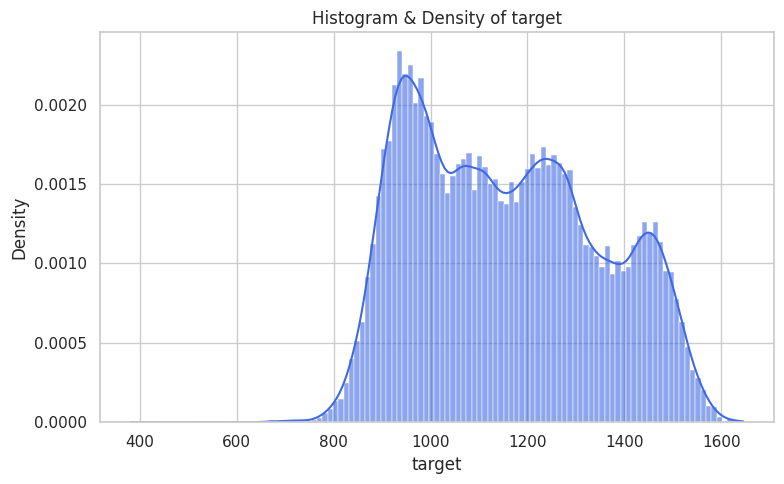

In [3]:
# LOAD & PREPROCESS DATA (Cleaned up via data_loader)
pan_loaded_data = pan_load()  # Uses default continuous_dataset.csv
print("\n--- Panama (PAN) Electricity Load Dataset ---")
print(pan_loaded_data)
pan_preprocessing(pan_loaded_data)

# Display summary statistics and distribution of the target variable
pan_context_df = pd.read_csv(DATA_DIR / "processed" / "pan_context_df.csv")
print("\n--- Target Variable Summary Statistics ---")
print(compute_summary_statistics(pan_context_df, columns=[TARGET_COLUMN]))
plot_distribution(pan_context_df, columns=[TARGET_COLUMN])

1.2. Australia


--- Australia (AUS) Electricity Load Dataset ---
Loaded Data:   series_name state start_timestamp  \
0          T1   NSW      2002-01-01   
1          T2   VIC      2002-01-01   
2          T3   QUN      2002-01-01   
3          T4    SA      2002-01-01   
4          T5   TAS      2002-01-01   

                                        series_value  
0  [5714.045004, 5360.189078, 5014.835118, 4602.7...  
1  [3535.867064, 3383.499028, 3655.527552, 3510.4...  
2  [3382.041342, 3288.315794, 3172.329022, 3020.3...  
3  [1191.078014, 1219.589472, 1119.173498, 1016.4...  
4  [315.915504, 306.245864, 305.762576, 295.60219...  
Data Frequency: half_hourly
Suggested Forecast Horizon: None
Contains Missing Values?: False
Are all series of Equal Length?: False

[SUCCESS] Preprocessing complete! The dataset is ready to be fed to Chronos-2.

--- Target Variable Summary Statistics ---
               target
count   183960.000000
mean      1311.111941
median    1288.984671
var      89703.646830
min   

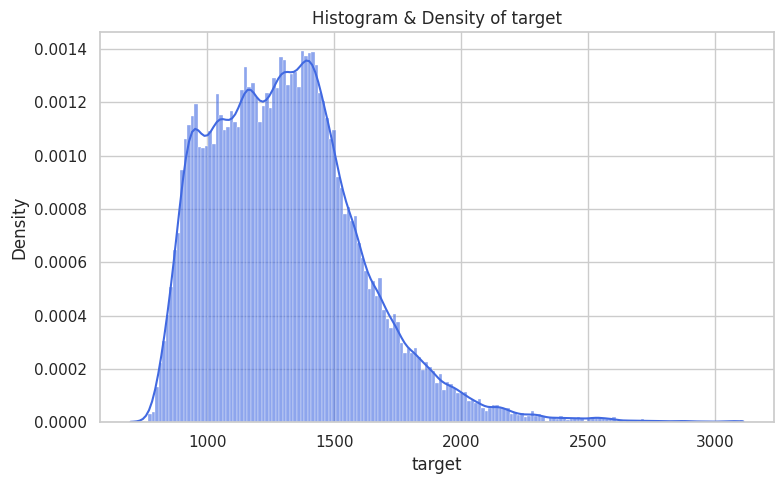

In [4]:
# LOAD & PREPROCESS DATA (Cleaned up via data_loader)
aus_loaded_data, aus_frequency, aus_forecast_horizon, aus_contain_missing_values, aus_contain_equal_length = aus_convert_tsf_to_dataframe(DATA_DIR / "raw" / "australian_electricity_demand_dataset.tsf")

print("\n--- Australia (AUS) Electricity Load Dataset ---")
print(f"Loaded Data: {aus_loaded_data}")
print(f"Data Frequency: {aus_frequency}")
print(f"Suggested Forecast Horizon: {aus_forecast_horizon}")
print(f"Contains Missing Values?: {aus_contain_missing_values}")
print(f"Are all series of Equal Length?: {aus_contain_equal_length}")

aus_preprocessing(aus_loaded_data)

# Display summary statistics and distribution of the target variable
aus_context_df = pd.read_csv(DATA_DIR / "processed" / "aus_context_df.csv")
print("\n--- Target Variable Summary Statistics ---")
print(compute_summary_statistics(aus_context_df, columns=[TARGET_COLUMN]))
plot_distribution(aus_context_df, columns=[TARGET_COLUMN])

## 2 — Load Chronos-2
Downloads ~700 MB on first run, cached locally after that.

In [5]:
disable_progress_bar()

pipeline = Chronos2Pipeline.from_pretrained(
    MODEL_ID,                     # "amazon/chronos-2"  (set in config.py)
    device_map = "cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype = torch.bfloat16, # use float32 if you get dtype errors on CPU
)

print(f"Loaded {MODEL_ID}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loaded amazon/chronos-2


---
## S1 — Univariate Baseline (zero-shot)
Chronos-2 on raw demand only.

Predictions successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_pred.csv'.
Metrics successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_res.csv'.
Predictions successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/aus_pred.csv'.
Metrics successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/aus_res.csv'.


--- Panama (PAN) Electricity Load Time Series Forecasting Plot ---


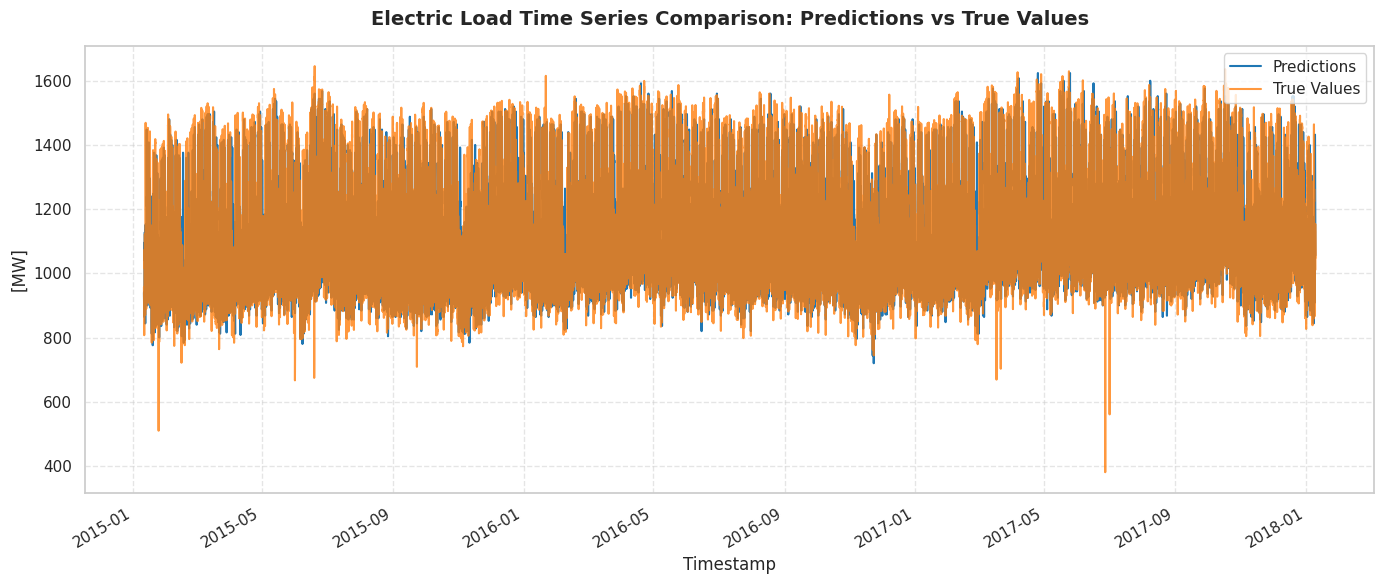

Plot successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_time_series.png'.


--- Australia (AUS) Electricity Load Time Series Forecasting Plot ---


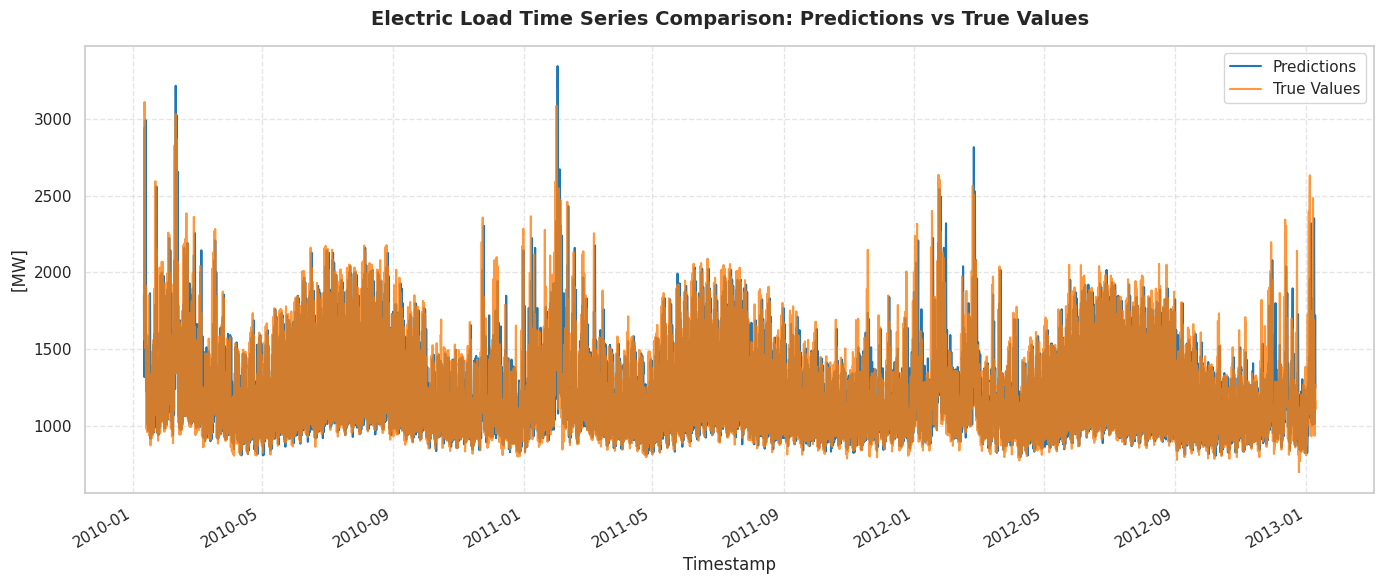

Plot successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/aus_time_series.png'.


In [6]:
# Predict electric load and evaluate the result
pan_context_df = pd.read_csv(DATA_DIR / "processed" / "pan_context_df.csv")
pan_ground_truth = np.load(DATA_DIR / "processed" / "pan_horizon_true.npy")

aus_context_df = pd.read_csv(DATA_DIR / "processed" / "aus_context_df.csv")
aus_ground_truth = np.load(DATA_DIR / "processed" / "aus_horizon_true.npy")

pan_pred = s1_predict(pipeline, pan_context_df, save_path = RESULTS_DIR / "pan_pred.csv")
pan_res = s1_evaluation(pan_pred, pan_ground_truth, save_path = RESULTS_DIR / "pan_res.csv")

aus_pred = s1_predict(pipeline, aus_context_df, save_path = RESULTS_DIR / "aus_pred.csv")
aus_res = s1_evaluation(aus_pred, aus_ground_truth, save_path = RESULTS_DIR / "aus_res.csv")
print("\n")

print("--- Panama (PAN) Electricity Load Time Series Forecasting Plot ---")
plot_time_series(pan_pred, pan_ground_truth, RESULTS_DIR / "pan_time_series.png")
print("\n")

print("--- Australia (AUS) Electricity Load Time Series Forecasting Plot ---")
plot_time_series(aus_pred, aus_ground_truth, RESULTS_DIR / "aus_time_series.png")

--- Panama (PAN) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean      51.252376     3.548775
median    38.102233     2.644769
var     1756.512366     8.546343
min       10.481519     0.639755
q1        26.397906     1.840085
q3        56.894259     4.044634
max      299.031875    23.428759


--- Australia (AUS) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean     103.582979     6.005030
median    70.236560     4.143556
var     9834.543333    29.026093
min        9.394003     0.640214
q1        45.377168     2.767359
q3       122.612995     7.251530
max      870.514888    46.304512


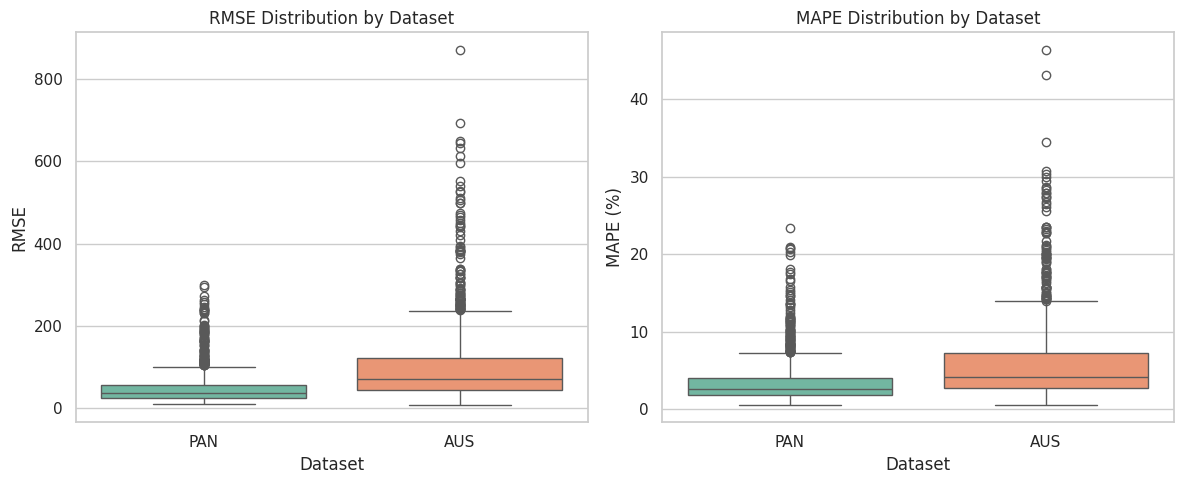

Box plots successfully created and saved.


In [7]:
# Display Summary Statistics of the resulting Accuracy Metrics
print("--- Panama (PAN) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(pan_res, columns=['rmse', 'mape']))
print("\n")
print("--- Australia (AUS) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(aus_res, columns=['rmse', 'mape']))

# Combine pan_res and aus_res vertically
merged_res_df = pd.concat([pan_res, aus_res], ignore_index=True)

# Make summary boxplots
plot_metrics_boxplots(merged_res_df)

---
## S2 — Covariate-Informed Forecasting
Weather (T2M, QV2M, W2M, PS) + calendar features via `predict_df(future_df=...)` — **RQ1.1, RQ1.2**.

---
## S3a — Cross-City Learning
Feed per-city temperature series (Tocumen, Santiago, David) alongside national demand — **RQ1.1, RQ1.2**.

---
## S3b — STL Decomposition Cross-Learning
Decompose demand → trend + seasonal (24 h) + residual, feed all as separate series — **RQ1.1, RQ1.2**.

---
## S4 — Ensemble-Based Forecasting
10 weather realisations → average (mirrors Copernicus ERA5 EDA) — **RQ1.1, RQ1.2**.

---
## Results Summary